# Enjambre de Partículas
### Optimización: Programación Estructurada vs Enjambre de Partículas

**Función a minimizar**

$$f(x, y) = x^2 \left(4 - 2.1x^2 + \frac{x^4}{3}\right) + xy + y^2(-4 + 4y^2)$$

**Dominio:** $x \in [-2, 2]$, $y \in [-1, 1]$

Los mínimos globales conocidos son aproximadamente $f \approx -1.0316$ en $(0.0898, -0.7126)$ y $(-0.0898, 0.7126)$.

## 0. Importaciones y función objetivo

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time
from random import random

# Funcion
def funcion(x, y):

    sum1 = x**2 * (4 - 2.1*x**2 + x**4/3.0)
    sum2 = x * y
    sum3 = y**2 * (-4 + 4*y**2)
    return sum1 + sum2 + sum3

## 2. Método 1: Programación Estructurada

In [11]:
def busqueda_rejilla(pasos=1000):
    # Recorre una rejilla uniforme sobre el dominio y devuelve el punto con menor valor de f(x, y)

    mejor_x = None
    mejor_y = None
    mejor_val = float('inf')
    historial = []

    xs = np.linspace(-2,  2, pasos)
    ys = np.linspace(-1,  1, pasos)

    for x in xs:
        for y in ys:
            val = funcion(x, y)
            if val < mejor_val:
                mejor_val = val
                mejor_x = x
                mejor_y = y
                historial.append((mejor_x, mejor_y, mejor_val))

    return mejor_x, mejor_y, mejor_val, historial

t0 = time.time()
gx, gy, gval, g_hist = busqueda_rejilla(pasos=500)
t_grid = time.time() - t0

print(f" x = {gx:.6f}")
print(f" y = {gy:.6f}")
print(f" f(x,y) = {gval:.6f}")
print(f" Tiempo = {t_grid:.4f} s")

 x = -0.092184
 y = 0.711423
 f(x,y) = -1.031592
 Tiempo = 0.1724 s


### 2.2 Descenso de Gradiente (Gradient Descent)

In [12]:
def gradiente_numerico(x, y, h=1e-6):
    """Gradiente numérico centrado."""
    df_dx = (funcion(x + h, y) - funcion(x - h, y)) / (2 * h)
    df_dy = (funcion(x, y + h) - funcion(x, y - h)) / (2 * h)
    return df_dx, df_dy


def descenso_gradiente(x0, y0, lr=0.01, iteraciones=5000, tol=1e-9):
    """
    Descenso de gradiente clásico con clipping al dominio.
    Retorna el mínimo encontrado y el historial de valores.
    """
    x, y      = x0, y0
    historial = [funcion(x, y)]

    for _ in range(iteraciones):
        gx, gy = gradiente_numerico(x, y)
        x_new  = np.clip(x - lr * gx, -2, 2)
        y_new  = np.clip(y - lr * gy, -1, 1)

        historial.append(funcion(x_new, y_new))

        if abs(x_new - x) < tol and abs(y_new - y) < tol:
            x, y = x_new, y_new
            break
        x, y = x_new, y_new

    return x, y, funcion(x, y), historial


# ─── Multi-start para escapar mínimos locales ──────────────────────────────────
np.random.seed(42)
n_starts  = 30
mejor_gd  = (None, None, float('inf'), [])

t0 = time.time()
for _ in range(n_starts):
    x0 = np.random.uniform(-2, 2)
    y0 = np.random.uniform(-1, 1)
    rx, ry, rv, rh = descenso_gradiente(x0, y0)
    if rv < mejor_gd[2]:
        mejor_gd = (rx, ry, rv, rh)

t_gd = time.time() - t0
gdx, gdy, gdval, gd_hist = mejor_gd

print("=== Descenso de Gradiente (multi-start) ===")
print(f"  x      = {gdx:.6f}")
print(f"  y      = {gdy:.6f}")
print(f"  f(x,y) = {gdval:.6f}")
print(f"  Tiempo = {t_gd:.4f} s")

=== Descenso de Gradiente (multi-start) ===
  x      = -0.089842
  y      = 0.712656
  f(x,y) = -1.031628
  Tiempo = 0.0656 s


---
## 3. Método 2 – Enjambre de Partículas (PSO)

Implementación fiel al código del libro (Benítez Iglésias, 2014), con inercia decreciente.

In [13]:
from random import random as rnd

# Clase Particula
class Particula:
    # Atributos de clase (compartidos por todas las partículas)
    inercia = 1.4
    cognitiva = 2.0
    social = 2.0
    # Límites del espacio de soluciones
    infx = -10.0;  
    supx = 10.0
    infy = -10.0;  
    supy = 10.0
    # Factor de ajuste de la velocidad inicial
    ajusteV = 100.0

    def __init__(self):
        # Posición aleatoria dentro de los límites
        self.x = aleatorio(Particula.infx, Particula.supx)
        self.y = aleatorio(Particula.infy, Particula.supy)
        # Velocidad inicial aleatoria escalada
        self.vx = aleatorio(Particula.infx / Particula.ajusteV,
                            Particula.supx / Particula.ajusteV)
        self.vy = aleatorio(Particula.infy / Particula.ajusteV,
                            Particula.supy / Particula.ajusteV)
        # Mejor posición local
        self.xLoc     = self.x
        self.yLoc     = self.y
        self.valorLoc = funcion(self.x, self.y)

    def actualizaVelocidad(self, xGlob, yGlob):
        cogX = Particula.cognitiva * rnd() * (self.xLoc - self.x)
        socX = Particula.social    * rnd() * (xGlob    - self.x)
        self.vx = Particula.inercia * self.vx + cogX + socX

        cogY = Particula.cognitiva * rnd() * (self.yLoc - self.y)
        socY = Particula.social    * rnd() * (yGlob    - self.y)
        self.vy = Particula.inercia * self.vy + cogY + socY

    def actualizaPosicion(self):
        self.x = self.x + self.vx
        self.y = self.y + self.vy
        # Mantener dentro del espacio de soluciones
        self.x = max(self.x, Particula.infx)
        self.x = min(self.x, Particula.supx)
        self.y = max(self.y, Particula.infy)
        self.y = min(self.y, Particula.supy)
        # Si es mejor que el local, actualizar
        valor = funcion(self.x, self.y)
        if valor < self.valorLoc:
            self.xLoc     = self.x
            self.yLoc     = self.y
            self.valorLoc = valor


def aleatorio(inf, sup):
    return rnd() * (sup - inf) + inf


# Algoritmo PSO
def enjambreParticulas(particulas, iteraciones, reduccionInercia):
    """
    Mueve el enjambre durante las iteraciones indicadas.
    Devuelve coordenadas y valor del mínimo obtenido,
    más el historial del mejor valor global por iteración.
    """
    # Registra la mejor posición global inicial
    mejorParticula = min(particulas, key=lambda p: p.valorLoc)
    xGlob     = mejorParticula.xLoc
    yGlob     = mejorParticula.yLoc
    valorGlob = mejorParticula.valorLoc
    historial = [valorGlob]

    for _ in range(iteraciones):
        # Actualiza velocidad y posición de cada partícula
        for p in particulas:
            p.actualizaVelocidad(xGlob, yGlob)
            p.actualizaPosicion()

        # Actualiza el mínimo global
        mejorParticula = min(particulas, key=lambda p: p.valorLoc)
        if mejorParticula.valorLoc < valorGlob:
            xGlob     = mejorParticula.xLoc
            yGlob     = mejorParticula.yLoc
            valorGlob = mejorParticula.valorLoc

        historial.append(valorGlob)
        # Reduce la inercia de todas las partículas
        Particula.inercia *= reduccionInercia

    return xGlob, yGlob, valorGlob, historial


# Parámetros del problema 
nParticulas = 10
iteraciones = 100
redInercia = 0.9

# Resetear inercia antes de cada ejecución
Particula.inercia = 1.4

# Genera el conjunto inicial de partículas
particulas = [Particula() for _ in range(nParticulas)]

t0 = time.time()
px, py, pval, p_hist = enjambreParticulas(particulas, iteraciones, redInercia)
t_pso = time.time() - t0

print("=== Enjambre de Partículas (PSO) ===")
print(f"  x = {px:.6f}")
print(f"  y = {py:.6f}")
print(f"  f(x,y) = {pval:.6f}")
print(f"  Tiempo = {t_pso:.4f} s")

=== Enjambre de Partículas (PSO) ===
  x = -0.089842
  y = 0.712656
  f(x,y) = -1.031628
  Tiempo = 0.0012 s


---
## 4. Comparación de resultados

In [14]:
minimo_global = -1.031628

print("╔══════════════════════════════════════════════════════════════════╗")
print("║                COMPARATIVA DE MÉTODOS DE OPTIMIZACIÓN           ║")
print("╠══════════════════╦══════════╦══════════╦══════════╦═════════════╣")
print("║ Método           ║    x     ║    y     ║  f(x,y)  ║  Tiempo (s) ║")
print("╠══════════════════╬══════════╬══════════╬══════════╬═════════════╣")
print(f"║ Mínimo global    ║  0.0898  ║ -0.7126  ║ -1.03163 ║      —      ║")
print(f"║ Búsqueda rejilla ║ {gx:8.4f} ║ {gy:8.4f} ║ {gval:8.5f} ║ {t_grid:11.4f} ║")
print(f"║ Desc. gradiente  ║ {gdx:8.4f} ║ {gdy:8.4f} ║ {gdval:8.5f} ║ {t_gd:11.4f} ║")
print(f"║ PSO (enjambre)   ║ {px:8.4f} ║ {py:8.4f} ║ {pval:8.5f} ║ {t_pso:11.4f} ║")
print("╚══════════════════╩══════════╩══════════╩══════════╩═════════════╝")

print("\nError absoluto respecto al mínimo global conocido:")
print(f"  Búsqueda rejilla : {abs(gval  - minimo_global):.2e}")
print(f"  Desc. gradiente  : {abs(gdval - minimo_global):.2e}")
print(f"  PSO (enjambre)   : {abs(pval  - minimo_global):.2e}")

╔══════════════════════════════════════════════════════════════════╗
║                COMPARATIVA DE MÉTODOS DE OPTIMIZACIÓN           ║
╠══════════════════╦══════════╦══════════╦══════════╦═════════════╣
║ Método           ║    x     ║    y     ║  f(x,y)  ║  Tiempo (s) ║
╠══════════════════╬══════════╬══════════╬══════════╬═════════════╣
║ Mínimo global    ║  0.0898  ║ -0.7126  ║ -1.03163 ║      —      ║
║ Búsqueda rejilla ║  -0.0922 ║   0.7114 ║ -1.03159 ║      0.1724 ║
║ Desc. gradiente  ║  -0.0898 ║   0.7127 ║ -1.03163 ║      0.0656 ║
║ PSO (enjambre)   ║  -0.0898 ║   0.7127 ║ -1.03163 ║      0.0012 ║
╚══════════════════╩══════════╩══════════╩══════════╩═════════════╝

Error absoluto respecto al mínimo global conocido:
  Búsqueda rejilla : 3.63e-05
  Desc. gradiente  : 4.53e-07
  PSO (enjambre)   : 4.53e-07


## 5. Gráficas comparativas

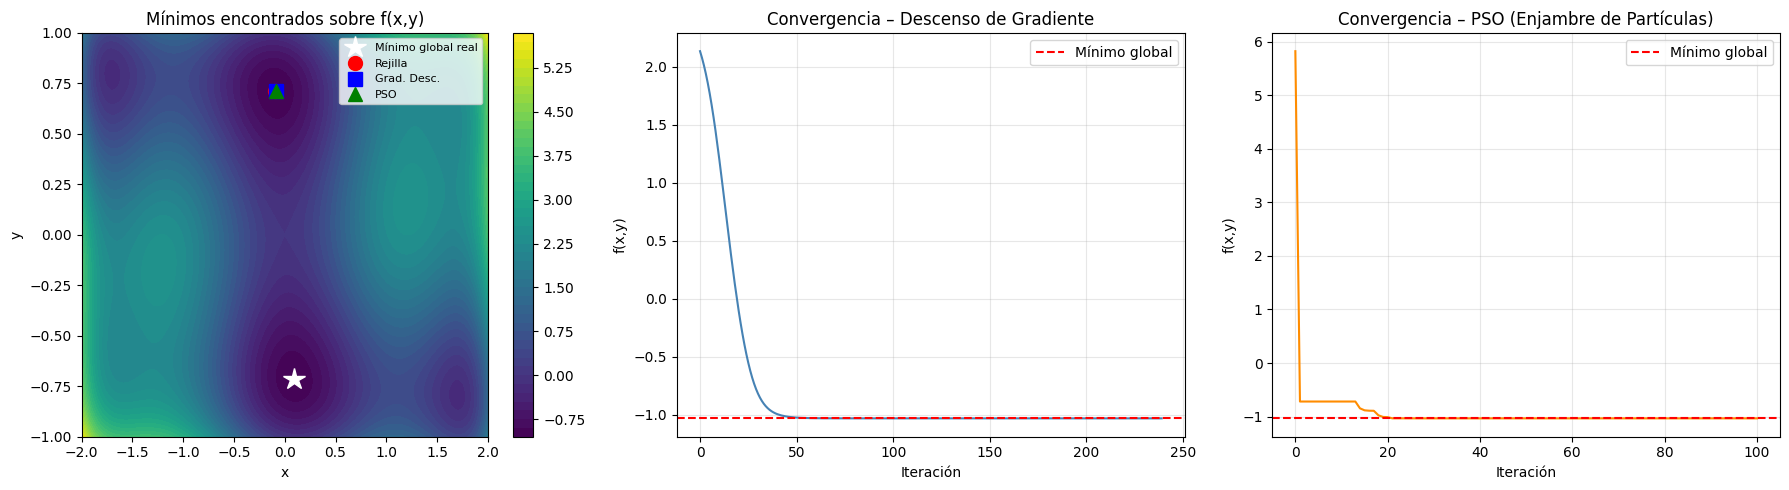

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Mapa de calor con los tres resultados ─────────────────────────────────────
ax = axes[0]
cf = ax.contourf(X, Y, Z, levels=50, cmap='viridis')
fig.colorbar(cf, ax=ax)
ax.set_title('Mínimos encontrados sobre f(x,y)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.plot( 0.0898, -0.7126, 'w*', markersize=16, label='Mínimo global real')
ax.plot(gx,  gy,  'ro', markersize=10, label='Rejilla')
ax.plot(gdx, gdy, 'bs', markersize=10, label='Grad. Desc.')
ax.plot(px,  py,  'g^', markersize=10, label='PSO')
ax.legend(fontsize=8)

# ── Convergencia: Descenso de Gradiente ──────────────────────────────────────
ax = axes[1]
ax.plot(gd_hist, color='steelblue', linewidth=1.5)
ax.axhline(minimo_global, color='red', linestyle='--', label='Mínimo global')
ax.set_title('Convergencia – Descenso de Gradiente')
ax.set_xlabel('Iteración'); ax.set_ylabel('f(x,y)')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Convergencia: PSO ─────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(p_hist, color='darkorange', linewidth=1.5)
ax.axhline(minimo_global, color='red', linestyle='--', label='Mínimo global')
ax.set_title('Convergencia – PSO (Enjambre de Partículas)')
ax.set_xlabel('Iteración'); ax.set_ylabel('f(x,y)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis estadístico del PSO (múltiples corridas)

El PSO es estocástico, por lo que conviene evaluarlo con varias semillas.

Estadísticas PSO (30 corridas independientes):
  Media    : -1.031628
  Mínimo   : -1.031628
  Máximo   : -1.031628
  Desv. Est: 0.000000
  Éxitos (error < 0.01): 30/30


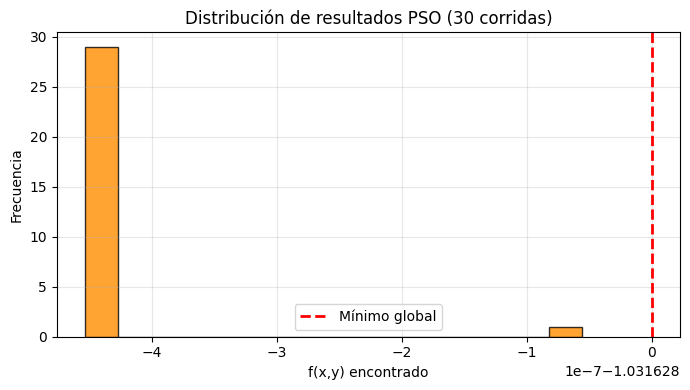

In [16]:
import random

N_corridas = 30
resultados_pso = []

for seed in range(N_corridas):
    random.seed(seed)
    Particula.inercia = 1.4          # Resetear inercia
    parts = [Particula() for _ in range(nParticulas)]
    _, _, val, _ = enjambreParticulas(parts, iteraciones, redInercia)
    resultados_pso.append(val)

resultados_pso = np.array(resultados_pso)

print(f"Estadísticas PSO ({N_corridas} corridas independientes):")
print(f"  Media    : {resultados_pso.mean():.6f}")
print(f"  Mínimo   : {resultados_pso.min():.6f}")
print(f"  Máximo   : {resultados_pso.max():.6f}")
print(f"  Desv. Est: {resultados_pso.std():.6f}")
print(f"  Éxitos (error < 0.01): {(abs(resultados_pso - minimo_global) < 0.01).sum()}/{N_corridas}")

# Histograma
plt.figure(figsize=(7, 4))
plt.hist(resultados_pso, bins=15, color='darkorange', edgecolor='black', alpha=0.8)
plt.axvline(minimo_global, color='red', linestyle='--', linewidth=2, label='Mínimo global')
plt.title(f'Distribución de resultados PSO ({N_corridas} corridas)')
plt.xlabel('f(x,y) encontrado'); plt.ylabel('Frecuencia')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Conclusiones

| Criterio | Búsqueda en Rejilla | Descenso de Gradiente | PSO |
|---|---|---|---|
| **Tipo** | Determinista | Determinista | Estocástico |
| **Garantía de óptimo global** | Alta (según resolución) | Baja (mínimos locales) | Moderada |
| **Costo computacional** | Muy alto (O(n²)) | Bajo | Medio |
| **Escalabilidad** | Muy baja | Alta | Alta |
| **Parámetros a ajustar** | Resolución de rejilla | Learning rate, tolerancia | Inercia, cognitiva, social |
| **Facilidad de implementación** | Muy simple | Simple | Moderada |

**Observaciones clave:**
- La **búsqueda en rejilla** garantiza encontrar el mínimo global si la resolución es suficiente, pero su costo es exponencial con la dimensión.
- El **descenso de gradiente** es rápido y preciso si parte cerca del mínimo, pero queda atrapado en mínimos locales. Con multi-start mejora considerablemente.
- El **PSO** balancea exploración y explotación de forma automática gracias a los parámetros cognitivo/social/inercia, y escala bien a problemas de alta dimensión sin requerir el cálculo del gradiente.